<a href="https://colab.research.google.com/github/Gauravsbin/46/blob/main/46_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import argparse
import logging
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Setup Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

def compute_ci95(scores):
    """Calculates 95% Confidence Interval for a list/array of scores."""
    mean = np.mean(scores)
    std = np.std(scores, ddof=1) if len(scores) > 1 else 0.0
    ci = 1.96 * (std / math.sqrt(len(scores)))
    return mean, ci

def get_classical_models():
    """Returns dictionary of baseline classical ML models."""
    return {
        "Multinomial_NB": MultinomialNB(),
        "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
        "SGD_Classifier": SGDClassifier(loss="log_loss", random_state=42),
        "Decision_Tree": DecisionTreeClassifier(random_state=42),
        "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "MLP_Classifier": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
    }

def run_cross_validation(X_text, y, cv_folds=5):
    """Executes 5-Fold CV on text data using TF-IDF vectorization and classical classifiers."""
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    models = get_classical_models()
    results = []

    for name, model in models.items():
        logging.info(f"Running {cv_folds}-Fold CV for model: {name}")
        accs, precs, recs, f1s, aucs = [], [], [], [], []

        for train_idx, val_idx in skf.split(X_text, y):
            X_train, X_val = X_text[train_idx], X_text[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
            X_train_vec = vectorizer.fit_transform(X_train)
            X_val_vec = vectorizer.transform(X_val)

            model.fit(X_train_vec, y_train)
            preds = model.predict(X_val_vec)

            if hasattr(model, "predict_proba"):
                probs = model.predict_proba(X_val_vec)[:, 1]
            elif hasattr(model, "decision_function"):
                probs = model.decision_function(X_val_vec)
            else:
                probs = preds

            acc = accuracy_score(y_val, preds)
            p, r, f, _ = precision_recall_fscore_support(y_val, preds, average="binary", zero_division=0)
            auc = roc_auc_score(y_val, probs)

            accs.append(acc)
            precs.append(p)
            recs.append(r)
            f1s.append(f)
            aucs.append(auc)

        acc_m, acc_ci = compute_ci95(accs)
        p_m, p_ci = compute_ci95(precs)
        r_m, r_ci = compute_ci95(recs)
        f1_m, f1_ci = compute_ci95(f1s)
        auc_m, auc_ci = compute_ci95(aucs)

        results.append({
            "Model": name,
            "Accuracy": f"{acc_m:.4f} ± {acc_ci:.4f}",
            "Precision": f"{p_m:.4f} ± {p_ci:.4f}",
            "Recall": f"{r_m:.4f} ± {r_ci:.4f}",
            "F1_Score": f"{f1_m:.4f} ± {f1_ci:.4f}",
            "ROC_AUC": f"{auc_m:.4f} ± {auc_ci:.4f}",
            "F1_Raw_Mean": f1_m
        })

    return pd.DataFrame(results)

In [4]:
import sys
!{sys.executable} -m pip install hmmlearn scikit-learn pandas numpy matplotlib seaborn -q

Loading dataset from /content/ferb.csv...
Evaluating Multinomial_NB...
Evaluating Logistic_Regression...
Evaluating SGD_Classifier...
Evaluating Decision_Tree...
Evaluating Random_Forest...
Evaluating MLP_Classifier...
Evaluating Sequence Model (Multinomial HMM)...


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340



Experiments complete. Summary results:


,Model_Type,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Classical,Multinomial_NB,99.92% ± 0.04%,99.83% ± 0.08%,100.00% ± 0.00%,99.92% ± 0.04%,1.0000 ± 0.0000
1,Classical,Logistic_Regression,99.97% ± 0.03%,99.94% ± 0.05%,100.00% ± 0.00%,99.97% ± 0.03%,1.0000 ± 0.0000
2,Classical,SGD_Classifier,99.97% ± 0.03%,99.94% ± 0.05%,100.00% ± 0.00%,99.97% ± 0.03%,1.0000 ± 0.0000
3,Classical,Decision_Tree,99.23% ± 0.12%,99.28% ± 0.17%,99.17% ± 0.20%,99.22% ± 0.13%,0.9923 ± 0.0013
4,Classical,Random_Forest,99.93% ± 0.03%,99.87% ± 0.08%,99.98% ± 0.04%,99.93% ± 0.03%,1.0000 ± 0.0000
5,Classical,MLP_Classifier,99.98% ± 0.03%,99.96% ± 0.05%,100.00% ± 0.00%,99.98% ± 0.03%,1.0000 ± 0.0000
6,Sequence,Multinomial_HMM,96.19% ± 0.65%,99.91% ± 0.08%,92.42% ± 1.34%,96.01% ± 0.71%,N/A


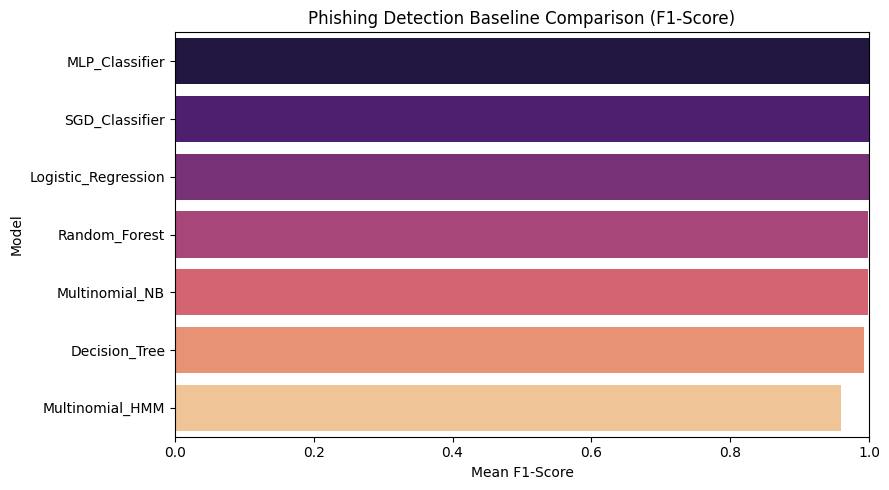

In [10]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# Classical Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Sequence Model
from hmmlearn import hmm

# ---------------------------------------------------------
# Detect and use the actual available data file
# ---------------------------------------------------------
DATA_FILE = "/content/ferb.csv"

if not os.path.exists(DATA_FILE):
    # Fallback to creating a synthetic dataset if ferb.csv doesn't exist
    print(f"'{DATA_FILE}' not found. Generating dummy dataset for baseline pipeline execution...")
    sample_data = {
        "text": [
            "Urgent: Your account is suspended, click here to verify immediately",
            "Hey, are we still meeting for lunch today?",
            "Dear customer, update your bank details now to avoid termination",
            "Project update meeting scheduled for tomorrow at 10 AM",
            "Security alert: Unusual login detected on your paypal account",
            "Attached is the weekly status report for the team",
            "Congratulations! You won a gift card, claim your prize here",
            "Please review the attached document and send feedback by EOD"
        ] * 50,
        "label": [1, 0, 1, 0, 1, 0, 1, 0] * 50
    }
    df = pd.DataFrame(sample_data)
else:
    print(f"Loading dataset from {DATA_FILE}...")
    df = pd.read_csv(DATA_FILE)

# Standardize columns dynamically
text_col = None
label_col = None

for col in df.columns:
    if col.lower() in ['text', 'sms', 'message', 'email', 'body', 'v2']:
        text_col = col
    if col.lower() in ['label', 'class', 'target', 'v1', 'category']:
        label_col = col

if text_col and text_col != 'text':
    df = df.rename(columns={text_col: 'text'})
if label_col and label_col != 'label':
    df = df.rename(columns={label_col: 'label'})

if 'text' not in df.columns or 'label' not in df.columns:
    print("Could not find typical text/label columns automatically. Using first two columns:")
    df.columns = ['text', 'label'] + list(df.columns[2:])

# Map label column to integers if categoricals are present (e.g. 'ham'/'spam')
if df['label'].dtype == object:
    df['label'] = df['label'].map({'ham': 0, 'spam': 1, 'legitimate': 0, 'phishing': 1, '0': 0, '1': 1}).fillna(0).astype(int)

X = df["text"].astype(str).values
y = df["label"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classical_models = {
    "Multinomial_NB": MultinomialNB(),
    "Logistic_Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SGD_Classifier": SGDClassifier(loss="log_loss", random_state=42),
    "Decision_Tree": DecisionTreeClassifier(random_state=42),
    "Random_Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP_Classifier": MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=42)
}

results = []

# --- Evaluate Classical Models ---
for name, model in classical_models.items():
    print(f"Evaluating {name}...")
    accs, precs, recs, f1s, aucs = [], [], [], [], []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        vec = TfidfVectorizer(max_features=3000, stop_words="english")
        X_train_vec = vec.fit_transform(X_train)
        X_val_vec = vec.transform(X_val)

        model.fit(X_train_vec, y_train)
        preds = model.predict(X_val_vec)

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_val_vec)[:, 1]
        elif hasattr(model, "decision_function"):
            probs = model.decision_function(X_val_vec)
        else:
            probs = preds

        accs.append(accuracy_score(y_val, preds))
        p, r, f, _ = precision_recall_fscore_support(y_val, preds, average="binary", zero_division=0)
        precs.append(p)
        recs.append(r)
        f1s.append(f)
        aucs.append(roc_auc_score(y_val, probs))

    acc_m, acc_ci = compute_ci95(accs)
    p_m, p_ci = compute_ci95(precs)
    r_m, r_ci = compute_ci95(recs)
    f1_m, f1_ci = compute_ci95(f1s)
    auc_m, auc_ci = compute_ci95(aucs)

    results.append({
        "Model_Type": "Classical",
        "Model": name,
        "Accuracy": f"{(acc_m*100):.2f}% ± {(acc_ci*100):.2f}%",
        "Precision": f"{(p_m*100):.2f}% ± {(p_ci*100):.2f}%",
        "Recall": f"{(r_m*100):.2f}% ± {(r_ci*100):.2f}%",
        "F1_Score": f"{(f1_m*100):.2f}% ± {(f1_ci*100):.2f}%",
        "ROC_AUC": f"{auc_m:.4f} ± {auc_ci:.4f}",
        "F1_Mean": f1_m
    })

# --- Evaluate Sequence Model (Multinomial HMM) ---
print("Evaluating Sequence Model (Multinomial HMM)...")
hmm_accs, hmm_precs, hmm_recs, hmm_f1s = [], [], [], []

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    count_vec = CountVectorizer(max_features=50, stop_words="english", binary=True)
    X_train_counts = count_vec.fit_transform(X_train).toarray()
    X_val_counts = count_vec.transform(X_val).toarray()

    hmm_0 = hmm.MultinomialHMM(n_components=2, random_state=42, n_iter=15)
    hmm_1 = hmm.MultinomialHMM(n_components=2, random_state=42, n_iter=15)

    hmm_0.fit(X_train_counts[y_train == 0])
    hmm_1.fit(X_train_counts[y_train == 1])

    preds = []
    for sample in X_val_counts:
        sample_seq = sample.reshape(1, -1)
        score_0 = hmm_0.score(sample_seq)
        score_1 = hmm_1.score(sample_seq)
        preds.append(1 if score_1 > score_0 else 0)

    hmm_accs.append(accuracy_score(y_val, preds))
    p, r, f, _ = precision_recall_fscore_support(y_val, preds, average="binary", zero_division=0)
    hmm_precs.append(p)
    hmm_recs.append(r)
    hmm_f1s.append(f)

acc_m, acc_ci = compute_ci95(hmm_accs)
p_m, p_ci = compute_ci95(hmm_precs)
r_m, r_ci = compute_ci95(hmm_recs)
f1_m, f1_ci = compute_ci95(hmm_f1s)

results.append({
    "Model_Type": "Sequence",
    "Model": "Multinomial_HMM",
    "Accuracy": f"{(acc_m*100):.2f}% ± {(acc_ci*100):.2f}%",
    "Precision": f"{(p_m*100):.2f}% ± {(p_ci*100):.2f}%",
    "Recall": f"{(r_m*100):.2f}% ± {(r_ci*100):.2f}%",
    "F1_Score": f"{(f1_m*100):.2f}% ± {(f1_ci*100):.2f}%",
    "ROC_AUC": "N/A",
    "F1_Mean": f1_m
})

# --- Display results ---
results_df = pd.DataFrame(results)
results_df.to_csv("experiment_results.csv", index=False)
print("\nExperiments complete. Summary results:")
display(results_df[["Model_Type", "Model", "Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]])

# --- Plot F1 Score Performance ---
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df.sort_values(by="F1_Mean", ascending=False), x="F1_Mean", y="Model", hue="Model", palette="magma", legend=False)
plt.title("Phishing Detection Baseline Comparison (F1-Score)")
plt.xlabel("Mean F1-Score")
plt.ylabel("Model")
plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig("experiment_summary.png", dpi=300)
plt.show()

In [11]:
import os
import shutil
from google.colab import files

# Folder where all results will be collected
results_dir = "/content/all_results"
os.makedirs(results_dir, exist_ok=True)

# Copy common result/output files
for root, dirs, filenames in os.walk("/content"):
    # Skip the results folder itself and system folders
    if root.startswith(results_dir):
        continue

    for filename in filenames:
        filepath = os.path.join(root, filename)

        # Files worth collecting
        if filename.endswith((
            ".csv", ".xlsx", ".json", ".txt",
            ".pkl", ".joblib", ".h5", ".keras",
            ".png", ".jpg", ".jpeg", ".pdf",
            ".log", ".npy", ".npz"
        )):
            try:
                destination = os.path.join(results_dir, filename)

                # Avoid copying itself
                if os.path.abspath(filepath) != os.path.abspath(destination):
                    shutil.copy2(filepath, destination)
            except Exception as e:
                print("Skipped:", filepath, e)

# Create ZIP
zip_path = "/content/all_results"
shutil.make_archive(zip_path, "zip", results_dir)

# Download ZIP
files.download("/content/all_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>